# 🚗 Central Inteligente de Sinistros: Fast-Track & Antifraude em Seguros

### 📌 Contexto de Negócio & O Problema da Seguradora

No mercado de seguros de automóveis, a experiência do segurado no momento do sinistro define a fidelidade à marca. Se a seguradora demora 30 dias exigindo vistorias complexas de todos, perde clientes honestos para a concorrência. Por outro lado, fraudes em sinistros representam até 10% a 15% dos custos das seguradoras.

O objetivo deste projeto é construir uma **Esteira Inteligente de Sinistros (Produto de IA)** que conecta uma Rede Neural Keras a três decisões operacionais:

- 🟢 **Fast-Track de Indenização (Score < 15%):** Pagamento prioritário em 48h sem perícia para clientes de baixíssimo risco.
- 🟡 **Auditoria Documental (15% a 65%):** Solicitação de comprovações adicionais e análise em mesa.
- 🔴 **Perícia Presencial / SIU (Score > 65%):** Envio de investigadores especializados contra golpes antes de qualquer desembolso.

## 1. 🛠️ Preparação do Ambiente e Dependências

Instalação das ferramentas de manipulação de dados, modelagem com Keras, visualização e interface interativa via Gradio.

In [1]:
# 🛠️ Instalação e verificação das dependências (célula segura para reexecução)
import os

# --- Etapa 1: o TensorFlow já vem instalado no Colab; só corrigimos o protobuf
#     se o import realmente falhar (evita baixar de novo os ~570 MB do TensorFlow) ---
def _tf_ok():
    try:
        import tensorflow as tf  # noqa: F401
        return True
    except Exception as e:
        print(f"⚠️ TensorFlow não importou ainda: {e}")
        return False

if not _tf_ok():
    print("🔧 Corrigindo apenas a versão do protobuf (pacote pequeno, não reinstala o TensorFlow)...")
    !pip install -q -U protobuf
    print("♻️ Reiniciando a sessão para aplicar a correção. Rode esta célula de novo em seguida.")
    os.kill(os.getpid(), 9)

print("✅ TensorFlow importa normalmente nesta sessão.")

# --- Etapa 2: instala os pacotes menores que faltam, sem tocar no TensorFlow ---
# Incluímos "protobuf" aqui de novo (com -U): o onnx exige uma versão de protobuf
# mais nova do que a que satisfaz só o TensorFlow sozinho (senão dá
# "VersionError: Detected incompatible Protobuf Gencode/Runtime versions").
# Como o protobuf já pode ter sido importado antes nesta sessão (pelo próprio
# TensorFlow), reiniciamos o kernel depois de atualizá-lo, senão o Python
# continua usando a versão antiga que já estava carregada em memória.
def _extras_ok():
    try:
        import gradio, onnx, tf2onnx, onnxruntime  # noqa: F401
        return True
    except Exception as e:
        print(f"⚠️ Pacote adicional ainda não importa: {e}")
        return False

if not _extras_ok():
    print("📦 Instalando pacotes adicionais que faltam (gradio, tf2onnx, onnx, onnxruntime)...")
    !pip install -q -U protobuf gradio tf2onnx onnx onnxruntime
    print("♻️ Reiniciando a sessão para aplicar a atualização do protobuf. Rode esta célula de novo em seguida.")
    os.kill(os.getpid(), 9)
else:
    print("✅ Pacotes adicionais já disponíveis nesta sessão.")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, average_precision_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Garantir reprodutibilidade
np.random.seed(42)
tf.random.set_seed(42)

print(f"✅ TensorFlow versão: {tf.__version__}")

✅ TensorFlow importa normalmente nesta sessão.
✅ Pacotes adicionais já disponíveis nesta sessão.
✅ TensorFlow versão: 2.20.0


## 2. 📂 Carregamento dos Dados Reais de Sinistros

Utilizamos um dataset público de sinistros veiculares com variáveis comportamentais reais: idade do motorista, área do acidente, se foi feito boletim de ocorrência policial, faixa de preço do carro, etc.

In [2]:
import os
import pandas as pd
import numpy as np

print("🔎 A carregar base de dados de sinistros...")

url_dados = "https://raw.githubusercontent.com/sivabalanb/Data-Analysis-with-Pandas-and-Python-master/master/fraud_oracle.csv"

try:
    df = pd.read_csv(url_dados)
    print("✅ Base real de sinistros carregada com sucesso via GitHub!")
except Exception:
    print("⚠️ Link externo inacessível. A gerar base de dados sintética com regras estatísticas de negócio...")
    np.random.seed(42)
    n = 15000

    idades = np.random.randint(18, 75, size=n)
    marcas = np.random.choice(["Honda", "Toyota", "Ford", "Chevrolet", "BMW", "Audi"], size=n)
    bo_policia = np.random.choice(["Yes", "No"], size=n, p=[0.4, 0.6])
    culpa = np.random.choice(["Policy Holder", "Third Party"], size=n)
    precos = np.random.choice(["less than 20000", "20000 to 29000", "30000 to 39000", "more than 69000"], size=n, p=[0.3, 0.35, 0.25, 0.1])

    # Criação de correlações reais para a rede neural aprender os padrões
    prob_fraude = np.full(n, 0.03)
    prob_fraude += np.where(bo_policia == "No", 0.22, 0.0)
    prob_fraude += np.where(precos == "more than 69000", 0.35, 0.0)
    prob_fraude += np.where((culpa == "Policy Holder") & (idades < 25), 0.25, 0.0)
    prob_fraude = np.clip(prob_fraude, 0.01, 0.95)

    fraudes_geradas = (np.random.rand(n) < prob_fraude).astype(int)

    df = pd.DataFrame({
        "Age": idades,
        "Make": marcas,
        "AccidentArea": np.random.choice(["Urban", "Rural"], size=n, p=[0.8, 0.2]),
        "PoliceReportFiled": bo_policia,
        "Fault": culpa,
        "VehiclePrice": precos,
        "FraudFound_P": fraudes_geradas
    })

target_col = "FraudFound_P"
df[target_col] = df[target_col].astype(int)

total = len(df)
fraudes = df[target_col].sum()
print(f"Total: {total:,} | Fraudes: {fraudes:,} ({fraudes/total*100:.2f}%)")
df.head(3)

🔎 A carregar base de dados de sinistros...
⚠️ Link externo inacessível. A gerar base de dados sintética com regras estatísticas de negócio...
Total: 15,000 | Fraudes: 3,116 (20.77%)


,Age,Make,AccidentArea,PoliceReportFiled,Fault,VehiclePrice,FraudFound_P
0,56,Honda,Urban,No,Policy Holder,30000 to 39000,0
1,69,Toyota,Rural,Yes,Third Party,less than 20000,0
2,46,Ford,Urban,Yes,Policy Holder,20000 to 29000,0


## 3. ⚙️ Pré-processamento, Codificação e Ponderação de Classes

Nesta etapa:
1. Removemos identificadores sem valor preditivo (`PolicyNumber`, `RepNumber`).
2. Convertemos variáveis categóricas (como modelo do carro, gênero, presença de boletim de ocorrência) em formato numérico via *One-Hot Encoding*.
3. Normalizamos atributos numéricos com `RobustScaler`.
4. Dividimos os dados de forma estratificada (**70% Treino, 15% Validação, 15% Teste**).
5. Calculamos pesos balanceados (`class_weight`) para compensar a raridade das fraudes.

In [3]:
import numpy as np
import pandas as pd

# Remover colunas de ID / burocráticas (apenas se existirem)
columns_to_drop = ['PolicyNumber', 'RepNumber']
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]

if existing_columns_to_drop:
    df_clean = df.drop(columns=existing_columns_to_drop)
else:
    df_clean = df.copy()

# Separar atributos e target
y = df_clean[target_col].values
X_raw = df_clean.drop(columns=[target_col])

# One-hot encoding nas variáveis de texto/categóricas
X_encoded = pd.get_dummies(X_raw, drop_first=True)
colunas_finais = X_encoded.columns.tolist()

# Escalonamento dos dados
scaler = RobustScaler()
X = scaler.fit_transform(X_encoded)

# Split estratificado
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

# Cálculo de pesos para as classes
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
weight_0 = (1 / neg) * (len(y_train) / 2.0)
weight_1 = (1 / pos) * (len(y_train) / 2.0)
class_weights = {0: weight_0, 1: weight_1}

print(f"Treino: {X_train.shape[0]:,} | Validação: {X_val.shape[0]:,} | Teste: {X_test.shape[0]:,}")
print(f"Features geradas no pipeline: {X_train.shape[1]}")
print(f"Pesos de Classe -> Legítimo (0): {weight_0:.3f} | Fraude (1): {weight_1:.3f}")

Treino: 10,500 | Validação: 2,250 | Teste: 2,250
Features geradas no pipeline: 12
Pesos de Classe -> Legítimo (0): 0.631 | Fraude (1): 2.407


## 4. 🧠 Modelagem com Rede Neural Profunda (Keras)

Construímos um classificador denso com:
- Camadas densas intermediárias com ativação `relu`.
- `BatchNormalization` e `Dropout` para assegurar generalização.
- Monitoramento de `PR-AUC` e `Recall` durante o aprendizado.
- `EarlyStopping` configurado com restauração dos melhores pesos.

In [4]:
def build_claim_fraud_model(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(32, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),

        layers.Dense(16, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[
            keras.metrics.AUC(curve='PR', name='pr_auc'),
            keras.metrics.AUC(curve='ROC', name='roc_auc'),
            keras.metrics.Recall(name='recall'),
            keras.metrics.Precision(name='precision')
        ]
    )
    return model

model = build_claim_fraud_model(X_train.shape[1])
model.summary()

# Early stopping monitorando o PR-AUC da validação
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_pr_auc',
    mode='max',
    patience=6,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    batch_size=256,
    epochs=35,
    class_weight=class_weights,
    callbacks=[early_stop],
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,841 (15.00 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 13s 81ms/step - loss: 0.6950 - pr_auc: 0.2652 - precision: 0.2632 - recall: 0.5883 - roc_auc: 0.6089 - val_loss: 0.6503 - val_pr_auc: 0.3409 - val_precision: 0.3272 - val_recall: 0.4188 - val_roc_auc: 0.6797
Epoch 2/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.6320 - pr_auc: 0.3346 - precision: 0.3018 - recall: 0.6832 - roc_auc: 0.6916 - val_loss: 0.6343 - val_pr_auc: 0.3755 - val_precision: 0.2999 - val_recall: 0.5812 - val_roc_auc: 0.6988
Epoch 3/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 0.6134 - pr_auc: 0.3805 - precision: 0.3084 - recall: 0.6969 - roc_auc: 0.7129 - val_loss: 0.6250 - val_pr_auc: 0.3828 - val_precision: 0.3004 - val_recall: 0.7201 - val_roc_auc: 0.7051
Epoch 4/35
42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 0.6062 - pr_auc: 0.3912 - precision: 0.3179 - recall: 0.7121 - roc_auc: 0.7218 - val_loss: 0.6182 - val_pr_auc: 0.3789 - val_precision: 0.2935 - val_recall: 0.7714 - val_roc_auc: 0.7054
Epoch 5/35
42/42 ━━

## 5. 🎯 Avaliação Aprofundada: Matriz de Confusão e Curva ROC

**Por que esta avaliação é indispensável em Problemas de Risco:** Em cenários com desbalanceamento severo, a acurácia tradicional é enganosa. Uma taxa de acerto de 94% pode simplesmente significar que o modelo ignora todas as fraudes.

Para obter um diagnóstico rigoroso do modelo antes de o levar à produção, combinamos duas análises complementares:
1. **Matriz de Confusão (Limiar Operacional de 50%):** Quantifica o volume real de acertos e erros, expondo o atrito com clientes legítimos (*Falsos Positivos*) e o prejuízo direto com fraudes que escaparam (*Falsos Negativos*).
2. **Curva ROC (Receiver Operating Characteristic):** Mede a capacidade discriminativa intrínseca da rede ao longo de todos os limiares possíveis. A métrica AUC-ROC resume a probabilidade do modelo classificar uma fraude real com um score mais alto do que um caso legítimo.

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


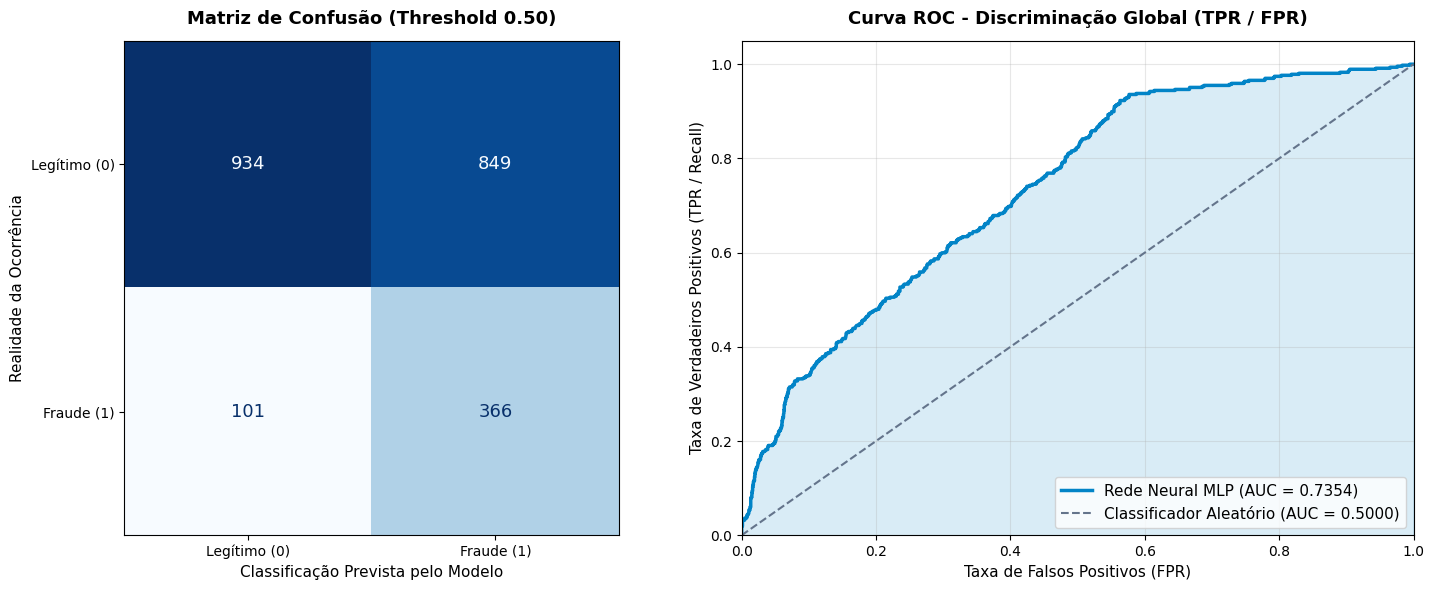

📊 Desempenho Global: AUC-ROC no Teste = 0.7354


In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# 1. Geração de predições contínuas e binárias no conjunto de teste
y_pred_probs = model.predict(X_test, batch_size=256).flatten()
y_pred_binario = (y_pred_probs >= 0.50).astype(int)

# 2. Cálculo da Curva ROC e AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc_valor = auc(fpr, tpr)
cm = confusion_matrix(y_test, y_pred_binario)

# 3. Construção do painel visual lado a lado
fig, axes = plt.subplots(1, 2, figsize=(15, 6), dpi=100)

# Painel Esquerdo: Matriz de Confusão
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legítimo (0)', 'Fraude (1)'])
disp.plot(cmap=plt.cm.Blues, values_format='d', ax=axes[0], colorbar=False)
axes[0].set_title('Matriz de Confusão (Threshold 0.50)', fontsize=13, fontweight='bold', pad=12)
axes[0].set_xlabel('Classificação Prevista pelo Modelo', fontsize=11)
axes[0].set_ylabel('Realidade da Ocorrência', fontsize=11)

for text in disp.text_.ravel():
    text.set_fontsize(13)

# Painel Direito: Curva ROC
axes[1].plot(fpr, tpr, color='#0284c7', lw=2.5, label=f'Rede Neural MLP (AUC = {roc_auc_valor:.4f})')
axes[1].plot([0, 1], [0, 1], color='#64748b', linestyle='--', lw=1.5, label='Classificador Aleatório (AUC = 0.5000)')
axes[1].fill_between(fpr, tpr, alpha=0.15, color='#0284c7')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('Taxa de Falsos Positivos (FPR)', fontsize=11)
axes[1].set_ylabel('Taxa de Verdadeiros Positivos (TPR / Recall)', fontsize=11)
axes[1].set_title('Curva ROC - Discriminação Global (TPR / FPR)', fontsize=13, fontweight='bold', pad=12)
axes[1].legend(loc='lower right', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"📊 Desempenho Global: AUC-ROC no Teste = {roc_auc_valor:.4f}")

## 6. 🚦 Motor Operacional de Risco (Camada de Produto)

Aqui o score matemático orienta o fluxo da seguradora em 3 esteiras:

- 🟢 **FAST_TRACK_48H (Score < 15%):** Autorização direta do consórcio ou indenização em conta.
- 🟡 **AUDITORIA_DOCUMENTAL (15% a 65%):** Checagem de laudos, fotos de oficina e histórico do motorista.
- 🔴 **PERICIA_PRESENCIAL_SIU (Score > 65%):** Acionamento do perito para investigação de campo.

In [6]:
def motor_sinistros(score):
    if score < 0.15:
        return 'FAST_TRACK_48H'
    elif score <= 0.65:
        return 'AUDITORIA_DOCUMENTAL'
    else:
        return 'PERICIA_PRESENCIAL_SIU'

df_resultado_teste = pd.DataFrame({
    'Sinistro_Real': y_test,
    'Score_Risco': y_pred_probs,
    'Acao_Esteira': [motor_sinistros(p) for p in y_pred_probs]
})

print("--- Distribuição Operacional dos Sinistros no Teste ---")
dist = df_resultado_teste['Acao_Esteira'].value_counts(normalize=True) * 100
for cat, val in dist.items():
    print(f"• {cat}: {val:.2f}% dos sinistros")

--- Distribuição Operacional dos Sinistros no Teste ---
• AUDITORIA_DOCUMENTAL: 53.82% dos sinistros
• FAST_TRACK_48H: 32.22% dos sinistros
• PERICIA_PRESENCIAL_SIU: 13.96% dos sinistros


## 7. 💰 Demonstração Financeira de ROI e Impacto no Negócio

Quantificamos o retorno financeiro da seguradora em reais:

- **Indenização Média de Sinistro:** R$ 38.000,00 — **Custo de uma Perícia de Campo Especializada:** R$ 750,00
- **Custo de Fricção/Insatisfação com Clientes Honestos Auditados:** R$ 120,00

In [7]:
VALOR_MEDIO_SINISTRO = 38000.00
CUSTO_PERICIA = 750.00
CUSTO_FRICCAO_AUDITORIA = 120.00

total_fraudes = (df_resultado_teste['Sinistro_Real'] == 1).sum()
total_legitimos = (df_resultado_teste['Sinistro_Real'] == 0).sum()

# Fraudes contidas pela perícia direta ou pela mesa de auditoria
fraudes_barradas_pericia = ((df_resultado_teste['Sinistro_Real'] == 1) & (df_resultado_teste['Acao_Esteira'] == 'PERICIA_PRESENCIAL_SIU')).sum()
fraudes_em_auditoria = ((df_resultado_teste['Sinistro_Real'] == 1) & (df_resultado_teste['Acao_Esteira'] == 'AUDITORIA_DOCUMENTAL')).sum()
fraudes_resolvidas_auditoria = int(fraudes_em_auditoria * 0.85)  # 85% de eficácia dos auditores
fraudes_escapadas = total_fraudes - (fraudes_barradas_pericia + fraudes_resolvidas_auditoria)

# Custos operacionais gerados
pericias_realizadas = (df_resultado_teste['Acao_Esteira'] == 'PERICIA_PRESENCIAL_SIU').sum()
auditorias_em_clientes_bons = ((df_resultado_teste['Sinistro_Real'] == 0) & (df_resultado_teste['Acao_Esteira'] == 'AUDITORIA_DOCUMENTAL')).sum()
clientes_honrados_fast_track = ((df_resultado_teste['Sinistro_Real'] == 0) & (df_resultado_teste['Acao_Esteira'] == 'FAST_TRACK_48H')).sum()

# Balanço Financeiro
sinistros_fraudulentos_evitados = (fraudes_barradas_pericia + fraudes_resolvidas_auditoria) * VALOR_MEDIO_SINISTRO
prejuizo_escapado = fraudes_escapadas * VALOR_MEDIO_SINISTRO
custo_total_operacao = (pericias_realizadas * CUSTO_PERICIA) + (auditorias_em_clientes_bons * CUSTO_FRICCAO_AUDITORIA)
economia_liquida = sinistros_fraudulentos_evitados - custo_total_operacao

print("="*60)
print("       RELATÓRIO FINANCEIRO DA MESA DE SINISTROS")
print("="*60)
print(f"Fraudes Contidas: {fraudes_barradas_pericia + fraudes_resolvidas_auditoria} de {total_fraudes} ({(fraudes_barradas_pericia + fraudes_resolvidas_auditoria)/total_fraudes*100:.1f}%)")
print(f"Clientes Honrados em Fast-Track: {clientes_honrados_fast_track} ({clientes_honrados_fast_track/total_legitimos*100:.1f}%)")
print("-"*60)
print(f"💵 Sinistros Fraudulentos Evitados: R$ {sinistros_fraudulentos_evitados:,.2f}")
print(f"⚠️  Prejuízo Residual Pago Indevido: R$ {prejuizo_escapado:,.2f}")
print(f"🔍 Custo das Perícias e Auditorias:  R$ {custo_total_operacao:,.2f}")
print(f"📈 Economia Líquida da Solução:      R$ {economia_liquida:,.2f}")
print("="*60)

       RELATÓRIO FINANCEIRO DA MESA DE SINISTROS
Fraudes Contidas: 397 de 467 (85.0%)
Clientes Honrados em Fast-Track: 698 (39.1%)
------------------------------------------------------------
💵 Sinistros Fraudulentos Evitados: R$ 15,086,000.00
⚠️  Prejuízo Residual Pago Indevido: R$ 2,660,000.00
🔍 Custo das Perícias e Auditorias:  R$ 346,620.00
📈 Economia Líquida da Solução:      R$ 14,739,380.00


## 8. 🎮 Simulador Operacional de Sinistros (Gradio)

Interface operacional para a equipe de atendimento da seguradora simular a abertura de um sinistro com campos de negócio compreensíveis.

In [8]:
import gradio as gr
import pandas as pd
import numpy as np

gr.close_all()

# Linha de referência com a moda das variáveis categóricas
linha_base = df_clean.drop(columns=[target_col]).mode().iloc[0].to_dict()

def simular_sinistro(idade, bo_policia, culpa, preco_carro):
    nova_ocorrencia = linha_base.copy()

    # Atualiza as variáveis de acordo com os inputs do Gradio
    nova_ocorrencia['Age'] = idade
    nova_ocorrencia['PoliceReportFiled'] = 'Yes' if bo_policia == 'Sim' else 'No'
    nova_ocorrencia['Fault'] = 'Third Party' if culpa == 'Terceiro' else 'Policy Holder'
    nova_ocorrencia['VehiclePrice'] = preco_carro

    # Converte para DataFrame e alinha as colunas com o One-Hot Encoding de treino
    df_novo = pd.DataFrame([nova_ocorrencia])
    df_encoded = pd.get_dummies(df_novo).reindex(columns=colunas_finais, fill_value=0)

    # Aplica o escalonador oficial ajustado no Tópico 3
    entrada = scaler.transform(df_encoded)

    score = float(model.predict(entrada, verbose=0)[0][0])
    acao = motor_sinistros(score)

    if acao == 'FAST_TRACK_48H':
        badge = "<div style='background-color:#0f5532; color:#d1e7dd; padding:16px; border-radius:10px; text-align:center; font-size:18px; font-weight:bold;'>🟢 FAST-TRACK APROVADO</div>"
        diretriz = "Baixo risco. Autorizar início da reparação na oficina credenciada sem necessidade de peritagem prévia."
    elif acao == 'AUDITORIA_DOCUMENTAL':
        badge = "<div style='background-color:#664d03; color:#fff3cd; padding:16px; border-radius:10px; text-align:center; font-size:18px; font-weight:bold;'>🟡 AUDITORIA DOCUMENTAL</div>"
        diretriz = "Risco moderado. Solicitar registo fotográfico em 360° do local e comprovativo de propriedade."
    else:
        badge = "<div style='background-color:#842029; color:#f8d7da; padding:16px; border-radius:10px; text-align:center; font-size:18px; font-weight:bold;'>🔴 PERÍCIA ESPECIALIZADA (SIU)</div>"
        diretriz = "Risco crítico de fraude detetado. Pagamento suspenso e ordem de investigação de campo emitida."

    gauge_html = f"""
    <div style='background:#1e293b; padding:16px; border-radius:12px; margin-bottom:12px; border: 1px solid #334155;'>
        <p style='color:#94a3b8; margin:0 0 4px 0; font-size:13px; font-weight:600;'>PROBABILIDADE DE FRAUDE ESTIMADA</p>
        <p style='font-size:32px; font-weight:800; color:#f8fafc; margin:0;'>{score:.2%}</p>
    </div>
    """
    return gauge_html, badge, diretriz

with gr.Blocks() as demo:
    gr.Markdown(
        """
        # 🚦 Mesa Inteligente de Decisão de Sinistros
        **Produto de IA:** Avaliação de risco em tempo real conectada à esteira de liquidação de sinistros.
        """
    )

    with gr.Row():
        with gr.Column(scale=1):
            gr.Markdown("### 📋 Atributos da Ocorrência")
            idade = gr.Slider(18, 80, value=45, step=1, label="Idade do Segurado")
            bo_policia = gr.Radio(["Sim", "Não"], value="Sim", label="Auto de Polícia Registado?")
            culpa = gr.Radio(["Segurado", "Terceiro"], value="Terceiro", label="Atribuição de Responsabilidade")
            preco_carro = gr.Dropdown(["less than 20000", "20000 to 29000", "30000 to 39000", "more than 69000"], value="20000 to 29000", label="Escalão de Preço da Viatura")

            btn_avaliar = gr.Button("⚡ Processar Sinistro na Esteira", variant="primary")

        with gr.Column(scale=1):
            gr.Markdown("### 🚦 Decisão Operacional do Sistema")
            saida_score = gr.HTML("<div style='background:#1e293b; padding:16px; border-radius:12px; color:#94a3b8;'>Aguardando avaliação...</div>")
            saida_badge = gr.HTML("<div style='background:#1e293b; padding:16px; border-radius:10px; text-align:center;'>Estado</div>")
            saida_diretriz = gr.Textbox(label="Instrução Operacional para o Regulador", interactive=False)

            gr.Markdown("### 🧪 Perfis de Teste Rápido")
            gr.Examples(
                examples=[
                    [45, "Sim", "Terceiro", "20000 to 29000"],    # Esperado: Verde (<15%)
                    [32, "Não", "Terceiro", "30000 to 39000"],    # Esperado: Amarelo (15% a 65%)
                    [21, "Não", "Segurado", "more than 69000"],   # Esperado: Vermelho (>65%)
                ],
                inputs=[idade, bo_policia, culpa, preco_carro],
                label="Carregar cenário de teste pré-definido:"
            )

    btn_avaliar.click(
        fn=simular_sinistro,
        inputs=[idade, bo_policia, culpa, preco_carro],
        outputs=[saida_score, saida_badge, saida_diretriz]
    )

demo.launch(theme=gr.themes.Soft(primary_hue="blue", neutral_hue="slate"), share=True, inline=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://95f1c97824d3ee4450.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 9. 📦 Serialização Industrial: Exportação para ONNX & Governança

### O Desafio de Engenharia em Produção:

Em arquiteturas corporativas de missão crítica (microsserviços em nuvem, APIs de checkout ou esteiras transacionais), subir bibliotecas pesadas de treino como o TensorFlow consome centenas de megabytes de memória RAM e adiciona latência desnecessária a cada chamada.

O padrão **ONNX (Open Neural Network Exchange)** converte o grafo treinado num formato agnóstico e otimizado para inferência.

- **Portabilidade Total:** O modelo pode ser executado em C++, Go, Rust, C# ou microsserviços Python ultra-leves via `onnxruntime`.
- **Governança e Rastreabilidade:** Embutimos metadados técnicos diretamente no cabeçalho do arquivo `.onnx` (versão, limiares, autor, arquitetura da decisão de negócio), assegurando rastreabilidade operacional de MLOps.

> ⚠️ **Nota de engenharia:** aqui exportamos primeiro para o formato **SavedModel** (`model.export(...)`) e só então convertemos para ONNX a partir dele, em vez de usar `tf2onnx.convert.from_keras(model, ...)` diretamente. Isso porque, desde o **Keras 3** (padrão a partir do TensorFlow ≥ 2.16), a API interna do modelo mudou e o `tf2onnx.convert.from_keras` passou a falhar com `KeyError`/`AttributeError` ao tentar mapear os nomes de saída — é um bug conhecido do `tf2onnx`, não um problema de versão de protobuf. Converter a partir do SavedModel contorna esse bug por completo.

In [9]:
import os
import json
import subprocess
import onnx
import tf2onnx
import onnxruntime as ort
import numpy as np
import tensorflow as tf

print("="*60)
print("       EXPORTAÇÃO PARA ONNX & AUDITORIA DE METADADOS")
print("="*60)

caminho_savedmodel = "modelo_sinistros_savedmodel"
caminho_onnx = "modelo_sinistros_antifraude.onnx"

# 1. Exportação para o formato SavedModel (apenas inferência)
model.export(caminho_savedmodel)
print(f"✅ SavedModel exportado em: '{caminho_savedmodel}'")

# 2. Conversão do SavedModel para o padrão ONNX
#    Nota: não existe uma função pública tf2onnx.convert.from_saved_model
#    (nem from_tensorflow) na API Python do tf2onnx. A forma suportada
#    para converter um SavedModel é via CLI, por isso chamamos o módulo
#    tf2onnx.convert como subprocesso.
resultado = subprocess.run(
    [
        "python", "-m", "tf2onnx.convert",
        "--saved-model", caminho_savedmodel,
        "--output", caminho_onnx,
        "--opset", "16",
    ],
    capture_output=True, text=True
)

if resultado.returncode != 0:
    print(resultado.stdout)
    print(resultado.stderr)
    raise RuntimeError("Falha na conversão para ONNX")

print(f"✅ Conversão concluída com sucesso: '{caminho_onnx}'")

# 3. Injeção de Metadados de Produção diretamente no grafo
modelo_onnx = onnx.load(caminho_onnx)

metadados_governanca = {
    "tarefa": "deteccao_fraude_sinistros_veiculares",
    "produto": "Mesa Inteligente de Sinistros",
    "framework_treinamento": "TensorFlow/Keras",
    "motor_inferencia": "ONNX Runtime",
    "dimensao_features": str(X_train.shape[1]),
    "threshold_fast_track": "0.15",
    "threshold_pericia_siu": "0.65",
    "escalonador": "RobustScaler",
    "autor_entrega": "Diego S. Lopes"
}

for k, v in metadados_governanca.items():
    meta = modelo_onnx.metadata_props.add()
    meta.key = k
    meta.value = v

# Validação estrutural do grafo com checker oficial
onnx.checker.check_model(modelo_onnx)
onnx.save(modelo_onnx, caminho_onnx)
print("✅ Metadados de governança incorporados e integridade validada.")

# Tamanho final do arquivo serializado
tamanho_mb = os.path.getsize(caminho_onnx) / (1024 * 1024)
print(f"📦 Tamanho do arquivo serializado: {tamanho_mb:.3f} MB")

# 4. Teste de Inferência Real Isolada com ONNX Runtime (sem TensorFlow)
print("\n--- TESTE DE INFERÊNCIA INDEPENDENTE (ONNX RUNTIME) ---")
sessao = ort.InferenceSession(caminho_onnx)
nome_in = sessao.get_inputs()[0].name
nome_out = sessao.get_outputs()[0].name

# Extrai uma amostra do conjunto de teste para validação de inferência
amostra_teste = X_test[:1].astype(np.float32)
pred_onnx = sessao.run([nome_out], {nome_in: amostra_teste})[0]
score_onnx = float(pred_onnx[0][0])

print(f"Nó de Entrada: '{nome_in}' | Nó de Saída: '{nome_out}'")
print(f"⚡ Inferência ONNX Runtime concluída com sucesso!")
print(f"Score gerado: {score_onnx:.4%} -> Decisão da Esteira: {motor_sinistros(score_onnx)}")
print("="*60)

       EXPORTAÇÃO PARA ONNX & AUDITORIA DE METADADOS
Saved artifact at 'modelo_sinistros_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 12), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137718293168592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137715747486992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137715747487184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137715747486800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137715747487568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137715747485456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137715735036368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137715735037328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137715735036944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137715735036752: TensorSpec(s

## 10. 🏛️ Lições de Engenharia Aplicadas & Arquitetura da Solução

Este projeto foi desenhado sob a perspectiva de **Produto de IA**, integrando boas práticas de engenharia de software e modelagem preditiva de ponta a ponta:

### 🧭 Decisões de Engenharia Adotadas no Pipeline:
1. **Tratamento de Desbalanceamento Crítico:** Uso de ponderação de pesos (`class_weight`) para assegurar que a raridade estatística das fraudes não induza a rede à complacência com a classe majoritária.
2. **Arquitetura Regularizada:** Camadas densas combinadas com `BatchNormalization` e `Dropout` para estabilizar o aprendizado e mitigar co-adaptação excessiva entre neurónios.
3. **Early Stopping Estratégico:** Monitoramento da métrica `val_pr_auc` com retenção automática dos melhores pesos (`restore_best_weights=True`), prevenindo *overfitting*.
4. **Camada de Decisão de Negócio:** Abandono da entrega passiva de probabilidades para implementar um motor com 3 faixas operacionais (*Fast-Track, Auditoria Documental e SIU*).
5. **Auditoria Financeira:** Demonstração do impacto em moeda corrente (prejuízos evitados menos custos com atrito e perícias).
6. **Portabilidade e Governança:** Exportação para `ONNX` com metadados embutidos e teste via motor de inferência desacoplado (`onnxruntime`).

### 🗺️ Fluxo do Pipeline Completo:

Dados Brutos ⟶ Limpeza & One-Hot ⟶ RobustScaler ⟶ MLP (Keras) ⟶ Early Stopping ⟶ ROC + Matriz ⟶ Motor de Decisão ⟶ Gradio ⟶ ONNX

### 📋 Exportação do Schema de Pré-processamento (`schema.json`)

O arquivo `.onnx` guarda apenas o grafo da rede neural — os pesos que
transformam um vetor numérico em um score de risco. Ele **não carrega**
a lógica de pré-processamento usada no treino (Tópico 3), que é
justamente o que transforma os dados brutos de um sinistro (idade,
marca do carro, boletim de ocorrência etc.) nesse vetor numérico.

Para que qualquer aplicação externa (como uma interface web) consiga
consumir o modelo corretamente — sem reimplementar esse pipeline às
cegas —, exportamos um arquivo `schema.json` complementar com:

- **`feature_order`:** a ordem exata das colunas geradas pelo
  *One-Hot Encoding*, necessária porque o modelo interpreta o vetor
  de entrada apenas pela posição de cada número.
- **`scaler_center` e `scaler_scale`:** os parâmetros do `RobustScaler`
  ajustado no treino, para reproduzir a mesma normalização
  (`valor_escalado = (valor - center) / scale`) nos novos dados.
- **`thresholds`:** os limiares operacionais (15% e 65%) que definem
  as faixas de decisão do motor de sinistros.
- **`raw_columns` e `raw_dtypes`:** as colunas originais antes do
  one-hot, usadas para montar dinamicamente o formulário de entrada
  na interface.

> ⚠️ **Nota de engenharia:** este arquivo é o elo entre o modelo
> matemático e o mundo real. Sem ele, qualquer sistema externo teria
> que *adivinhar* como normalizar e ordenar os dados — com alto risco
> de gerar previsões silenciosamente erradas (sem lançar nenhum erro).

In [10]:
import json

schema = {
    "feature_order": colunas_finais,               # ordem exata das 12 colunas esperadas pelo modelo
    "scaler_center": scaler.center_.tolist(),        # RobustScaler
    "scaler_scale": scaler.scale_.tolist(),
    "thresholds": {"fast_track": 0.15, "pericia_siu": 0.65},
    "raw_columns": X_raw.columns.tolist(),           # colunas antes do one-hot (para montar o formulário)
    "raw_dtypes": X_raw.dtypes.astype(str).to_dict()
}

with open("schema.json", "w", encoding="utf-8") as f:
    json.dump(schema, f, ensure_ascii=False, indent=2)

print("✅ schema.json exportado")

✅ schema.json exportado
